In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt

from depsi.network import (
    form_network,
    spatial_integration,
)
from depsi.densification import densification

In [2]:
# random number generator
rng = np.random.default_rng(42)

# Constants
wavelength = 0.055465763  # Sentinel-1, in meters
m2ph = -4 * np.pi / wavelength

# Configure the network and error parameters
id_ref = 3
arc_length_max = 70 # unitless based on az and range coords

In [3]:
# Network points true parameters
Npoints = 17  # Number of points
Ntimes = 29  # Number of epochs
time = np.linspace(0, 3, Ntimes)  # Time in years
pnt_vel_true = rng.uniform(-0.01, 0.01, (Npoints, ))  # Random velocities in m/yr
pnt_height_true = rng.uniform(1e-1, 1e0, (Npoints, ))  # Random heights in m
h2ph = rng.uniform(1e-3, 1e-2, (Npoints, Ntimes)) # Random height to phase conversion factors

# Simulate network points phase and ambiguities
phase_height = h2ph * m2ph * np.tile(pnt_height_true, (Ntimes, 1)).T
phase_vel = m2ph * np.tile(time, (Npoints, 1)) * np.tile(pnt_vel_true, (Ntimes, 1)).T
phase_true = phase_height + phase_vel
phase = (np.mod(phase_true + np.pi, 2 * np.pi)) - np.pi # wrpap the phase to [-pi, pi]
sd_phase = phase - np.tile(phase[:, 0], (Ntimes, 1)).T # reference to first epoch
ambiguities_true = np.round((phase_true - phase) / (2 * np.pi)).astype(int)

# Create the points
stm_pnts_network = xr.Dataset(
    data_vars={
        "sd_phase": (("space", "time"), sd_phase),
        "phase_true": (("space", "time"), phase_true),
        "h2ph": (("space", "time"), h2ph),
        "ambiguities_true": (
            ("space", "time"),
            ambiguities_true,
        ),
    },
    coords={
        "space": ("space", np.arange(Npoints)),
        "time": ("time", time),
        "azimuth": ("space", rng.integers(0, 100, Npoints)),
        "range": ("space", rng.integers(0, 100, Npoints)),
    },
)

In [4]:
# Construct arcs based on true ambiguities
stm_arcs_network = form_network(
    stm_pnts_network,
    key_xcrds="azimuth",
    key_ycrds="range",
    key_phase="sd_phase",
    key_h2ph="h2ph",
    key_Btemp="time",
    network_method="redundant",
    max_length=arc_length_max,
)
temp_coh = np.zeros((stm_arcs_network.sizes["space"],)) + 0.99 # All arcs by default have 0.99 temp_coh
stm_arcs_network["temp_coh"] = (("space"), temp_coh)

# Compute arc ambiguities from true point ambiguities, this assumes no mistakes in network arc periodogram estimation
ambigs = (
    stm_pnts_network["ambiguities_true"].values[stm_arcs_network["target"].values, :]
    - stm_pnts_network["ambiguities_true"].values[stm_arcs_network["source"].values, :]
)
stm_arcs_network["ambiguities"] = (("space", "time"), ambigs)

Text(0.5, 1.0, 'Network STM arcs, colored by temp_coh')

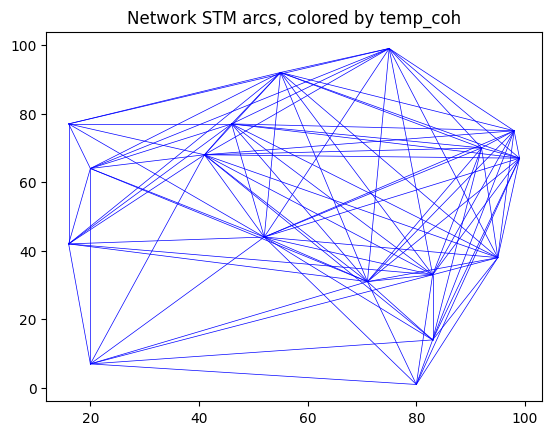

In [5]:
# Visualize network arcs
# x of sources and targets
xx = np.stack(
    [
        stm_pnts_network.isel(space=stm_arcs_network["source"])["range"].values,
        stm_pnts_network.isel(space=stm_arcs_network["target"])["range"].values,
    ]
).T
# y of sources and targets
yy = np.stack(
    [
        stm_pnts_network.isel(space=stm_arcs_network["source"])["azimuth"].values,
        stm_pnts_network.isel(space=stm_arcs_network["target"])["azimuth"].values,
    ]
).T
# Visualize created arcs
fig, ax = plt.subplots()
for i in range(stm_arcs_network.sizes["space"]):
    ax.plot(xx[i], yy[i], color='b', linewidth=0.5)
plt.title("Network STM arcs, colored by temp_coh")

In [6]:
# Network integration based on true arc ambiguities
stm_arcs_network_output, stm_pnts_network_output, id_ref_output = spatial_integration(stm_pnts_network, stm_arcs_network, idx_refpnt=id_ref)

/home/oku/Developments/MobyLe/DePSI_group/depsi/stats.py:360: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  lambda_init = fsolve(lambda lambda_init: _lambda_approx(lambda_init, df, gam0, cv), lstrt)


Text(0.5, 1.0, 'Difference (Estimated - True) Network Ambiguities (Reference Removed)')

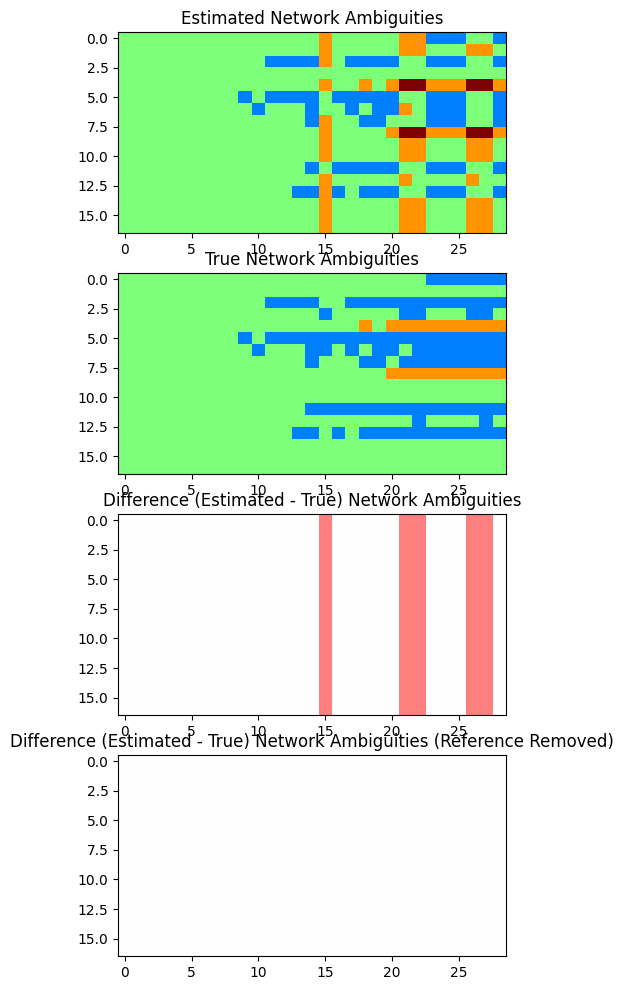

In [7]:
net_ambigs = stm_pnts_network_output["ambiguities"].values
net_ambigs_true = stm_pnts_network_output["ambiguities_true"].values
net_ambigs_diff = net_ambigs - net_ambigs_true
net_ambigs_diff_noref = net_ambigs_diff - net_ambigs_diff[id_ref_output, :]

fig, axes = plt.subplots(4, 1, figsize=(5, 12))
axes[0].imshow(net_ambigs, aspect="auto", cmap="jet", vmin=-2, vmax=2)
axes[0].set_title("Estimated Network Ambiguities")
axes[1].imshow(net_ambigs_true, aspect="auto", cmap="jet", vmin=-2, vmax=2)
axes[1].set_title("True Network Ambiguities")
axes[2].imshow(net_ambigs_diff, aspect="auto", cmap="bwr", vmin=-2, vmax=2)
axes[2].set_title("Difference (Estimated - True) Network Ambiguities")
axes[3].imshow(net_ambigs_diff_noref, aspect="auto", cmap="bwr", vmin=-2, vmax=2)
axes[3].set_title("Difference (Estimated - True) Network Ambiguities (Reference Removed)")

In [8]:
# Make densification datasets
Npoints = 50  # Number of points
Ntimes = 29  # Number of epochs
time = np.linspace(0, 3, Ntimes)  # Time in years
pnt_vel_true = rng.uniform(-0.01, 0.01, (Npoints, ))  # Random velocities in m/yr
pnt_height_true = rng.uniform(1e-1, 1e0, (Npoints, ))  # Random heights in m
h2ph = rng.uniform(1e-3, 1e-2, (Npoints, Ntimes))

# Simulate phases and ambiguities
phase_height = h2ph * m2ph * np.tile(pnt_height_true, (Ntimes, 1)).T
phase_vel = m2ph * np.tile(time, (Npoints, 1)) * np.tile(pnt_vel_true, (Ntimes, 1)).T
phase_true = phase_height + phase_vel
phase = (np.mod(phase_true + np.pi, 2 * np.pi)) - np.pi # wrpap the phase to [-pi, pi]
sd_phase = phase - np.tile(phase[:, 0], (Ntimes, 1)).T # reference to first epoch
ambiguities_true = np.round((phase_true - phase) / (2 * np.pi)).astype(int)


stm_pnt_densification = xr.Dataset(
    data_vars={
        "sd_phase": (("space", "time"), sd_phase),
        "phase_true": (("space", "time"), phase_true),
        "h2ph": (("space", "time"), h2ph),
        "ambiguities_true": (
            ("space", "time"),
            ambiguities_true,
        ),
    },
    coords={
        "space": ("space", np.arange(Npoints)),
        "time": ("time", time),
        "azimuth": ("space", rng.integers(20, 80, Npoints)),
        "range": ("space", rng.integers(20, 80, Npoints)),
    },
)

In [10]:
stm_densified = densification(
    stm_pnt_densification,
    stm_pnts_network_output,
    wavelength=wavelength,
    n_connections=1,
    key_xcoord="azimuth",
    key_ycoord="range",
    key_btemp="time",
    key_h2ph="h2ph",
    key_sdphase="sd_phase",
)

Text(0.5, 1.0, 'Difference (Estimated - True) Densification Ambiguities (Reference Removed)')

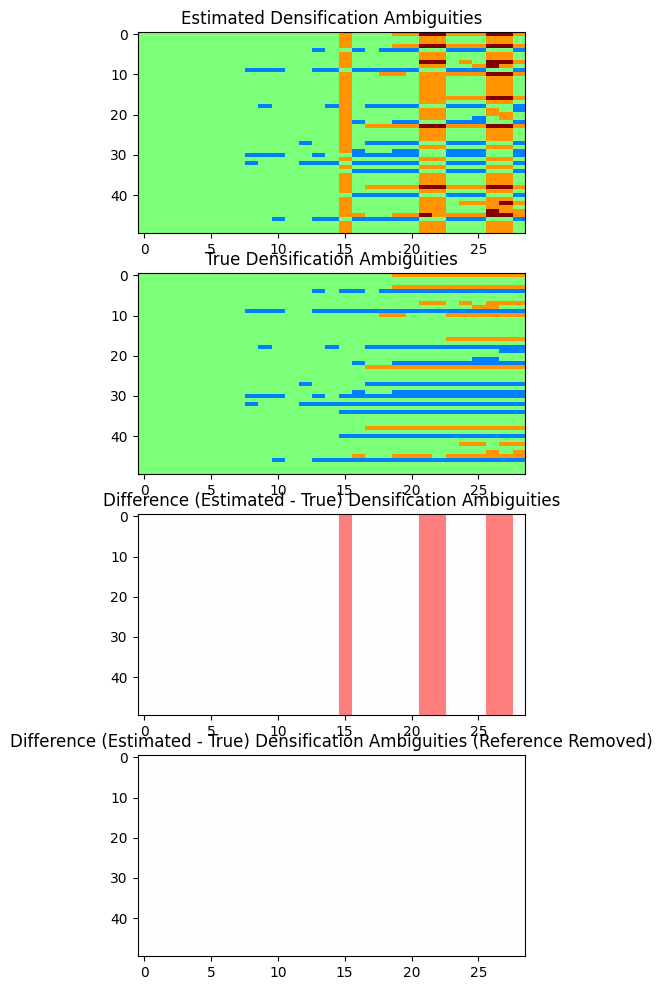

In [13]:
stm_densified_output = stm_densified.isel(space=range(stm_pnts_network_output.sizes["space"], stm_densified.sizes["space"]))

net_ambigs = stm_densified_output["ambiguities"].values
net_ambigs = net_ambigs - np.tile(net_ambigs[:, 0], (net_ambigs.shape[1], 1)).T
net_ambigs_true = stm_densified_output["ambiguities_true"].values
net_ambigs_diff = net_ambigs - net_ambigs_true
net_ambigs_diff_noref = net_ambigs_diff - net_ambigs_diff[id_ref_output, :]

fig, axes = plt.subplots(4, 1, figsize=(5, 12))
axes[0].imshow(net_ambigs, aspect="auto", cmap="jet", vmin=-2, vmax=2)
axes[0].set_title("Estimated Densification Ambiguities")
axes[1].imshow(net_ambigs_true, aspect="auto", cmap="jet", vmin=-2, vmax=2)
axes[1].set_title("True Densification Ambiguities")
axes[2].imshow(net_ambigs_diff, aspect="auto", cmap="bwr", vmin=-2, vmax=2)
axes[2].set_title("Difference (Estimated - True) Densification Ambiguities")
axes[3].imshow(net_ambigs_diff_noref, aspect="auto", cmap="bwr", vmin=-2, vmax=2)
axes[3].set_title("Difference (Estimated - True) Densification Ambiguities (Reference Removed)")